In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/sample_data/Social_Network_Ads.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [ ]:
df = df.iloc[:, 2:]
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [ ]:
X = df.iloc[:, 0:2].values
X

array([[    19,  19000],
       [    35,  20000],
       [    26,  43000],
       [    27,  57000],
       [    19,  76000],
       [    27,  58000],
       [    27,  84000],
       [    32, 150000],
       [    25,  33000],
       [    35,  65000],
       [    26,  80000],
       [    26,  52000],
       [    20,  86000],
       [    32,  18000],
       [    18,  82000],
       [    29,  80000],
       [    47,  25000],
       [    45,  26000],
       [    46,  28000],
       [    48,  29000],
       [    45,  22000],
       [    47,  49000],
       [    48,  41000],
       [    45,  22000],
       [    46,  23000],
       [    47,  20000],
       [    49,  28000],
       [    47,  30000],
       [    29,  43000],
       [    31,  18000],
       [    31,  74000],
       [    27, 137000],
       [    21,  16000],
       [    28,  44000],
       [    27,  90000],
       [    35,  27000],
       [    33,  28000],
       [    30,  49000],
       [    26,  72000],
       [    27,  31000],


In [ ]:
y = df.iloc[:, -1].values
y

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1,

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

In [ ]:
# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [ ]:
# Model
class Model(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(2, 128)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(128, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    x = self.relu(self.fc1(x))
    x = self.sigmoid(self.fc2(x))
    return x

In [ ]:
model = Model()

In [ ]:
# Loss & Optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Without Scaling

In [ ]:
# Training
epochs = 100
val_acc_list = []

for epoch in range(epochs):
  # Forward
  outputs = model(X_train)
  loss = criterion(outputs, y_train)

  # Backward
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Validation
  with torch.no_grad():
    val_outputs = model(X_test)
    preds = (val_outputs>0.5).float()
    acc = (preds == y_test).float().mean()
    val_acc_list.append(acc.item())

  if epoch%10 == 0:
    print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Val Acc: {acc.item():.4f}")

Epoch 0, Loss: 65.3125, Val Acc: 0.4000
Epoch 10, Loss: 65.3125, Val Acc: 0.4000
Epoch 20, Loss: 65.3125, Val Acc: 0.4000
Epoch 30, Loss: 65.3125, Val Acc: 0.4000
Epoch 40, Loss: 65.3125, Val Acc: 0.4000
Epoch 50, Loss: 65.3125, Val Acc: 0.4000
Epoch 60, Loss: 65.3125, Val Acc: 0.4000
Epoch 70, Loss: 65.3125, Val Acc: 0.4000
Epoch 80, Loss: 65.3125, Val Acc: 0.4000
Epoch 90, Loss: 65.3125, Val Acc: 0.4000


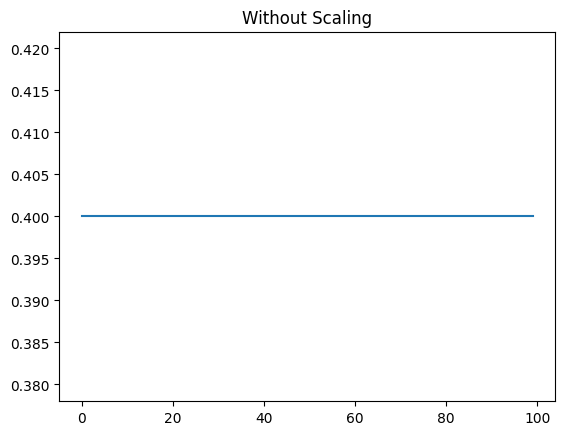

In [ ]:
# plot
plt.plot(val_acc_list)
plt.title("Without Scaling")
plt.show()

* No improvement at all

* Model is basically not learning anything

* This is exactly what we expect without scaling

# With Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

#scalling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.numpy())
X_test_scaled = scaler.transform(X_test.numpy())

# Convert back to tensor
X_train_scaled = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32)

# New Model
model = Model()

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epoch = 100
val_acc_list_scaled = []

for epoch in range(epochs):
  # Forward
  outputs = model(X_train_scaled)
  loss = criterion(outputs, y_train)

  # Backward
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Validation
  with torch.no_grad():
    val_outputs = model(X_test_scaled)
    preds = (val_outputs > 0.5).float()
    acc = (preds == y_test).float().mean()
    val_acc_list_scaled.append(acc.item())

  if epoch % 10 == 0:
      print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Val Acc: {acc.item():.4f}")

Epoch 0, Loss: 0.7162, Val Acc: 0.4875
Epoch 10, Loss: 0.6273, Val Acc: 0.7250
Epoch 20, Loss: 0.5569, Val Acc: 0.8125
Epoch 30, Loss: 0.5025, Val Acc: 0.8375
Epoch 40, Loss: 0.4604, Val Acc: 0.8250
Epoch 50, Loss: 0.4273, Val Acc: 0.8250
Epoch 60, Loss: 0.4006, Val Acc: 0.8375
Epoch 70, Loss: 0.3785, Val Acc: 0.8375
Epoch 80, Loss: 0.3599, Val Acc: 0.8500
Epoch 90, Loss: 0.3439, Val Acc: 0.8625


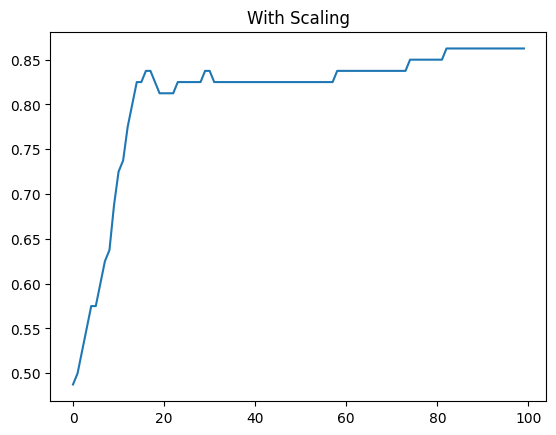

In [ ]:
# Plot
plt.plot(val_acc_list_scaled)
plt.title("With Scaling")
plt.show()